In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from pathlib import Path
import random
import shutil

# =========================
# Configuration
# =========================

SOURCE_DIR = Path("/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset")

TRAIN_DIR = Path("train")
VAL_DIR = Path("val")
TEST_DIR = Path("test")

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# =========================
# Check ratios
# =========================

assert TRAIN_RATIO + VAL_RATIO + TEST_RATIO == 1.0


# =========================
# Reproducible randomness
# =========================

random.seed(SEED)


# =========================
# Create output directories
# =========================

TRAIN_DIR.mkdir(exist_ok=True)
VAL_DIR.mkdir(exist_ok=True)
TEST_DIR.mkdir(exist_ok=True)


# =========================
# Process every class
# =========================

for class_dir in SOURCE_DIR.iterdir():

    # Ignore files
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name

    print(f"\nProcessing: {class_name}")

    # Get all images
    images = [
        image
        for image in class_dir.iterdir()
        if image.is_file()
        and image.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Shuffle images
    random.shuffle(images)

    total = len(images)

    # Calculate split sizes
    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    # Split images
    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    # Create class directories
    train_class_dir = TRAIN_DIR / class_name
    val_class_dir = VAL_DIR / class_name
    test_class_dir = TEST_DIR / class_name

    train_class_dir.mkdir(parents=True, exist_ok=True)
    val_class_dir.mkdir(parents=True, exist_ok=True)
    test_class_dir.mkdir(parents=True, exist_ok=True)

    # Copy images
    for image in train_images:
        shutil.copy2(image, train_class_dir / image.name)

    for image in val_images:
        shutil.copy2(image, val_class_dir / image.name)

    for image in test_images:
        shutil.copy2(image, test_class_dir / image.name)

    # Print statistics
    print(f"Total:      {total}")
    print(f"Train:      {len(train_images)}")
    print(f"Validation: {len(val_images)}")
    print(f"Test:       {len(test_images)}")


print("\nDataset split completed!")


Processing: glaucoma
Total:      1007
Train:      805
Validation: 100
Test:       102

Processing: normal
Total:      1074
Train:      859
Validation: 107
Test:       108

Processing: diabetic_retinopathy
Total:      1098
Train:      878
Validation: 109
Test:       111

Processing: cataract
Total:      1038
Train:      830
Validation: 103
Test:       105

Dataset split completed!


In [3]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/train",
    image_size=(224, 224),
    batch_size=32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/val",
    image_size=(224, 224),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/working/test",
    image_size=(224, 224),
    batch_size=32
)

print(train_dataset.class_names)

Found 3372 files belonging to 4 classes.


I0000 00:00:1787394735.265614      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 419 files belonging to 4 classes.
Found 426 files belonging to 4 classes.
['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


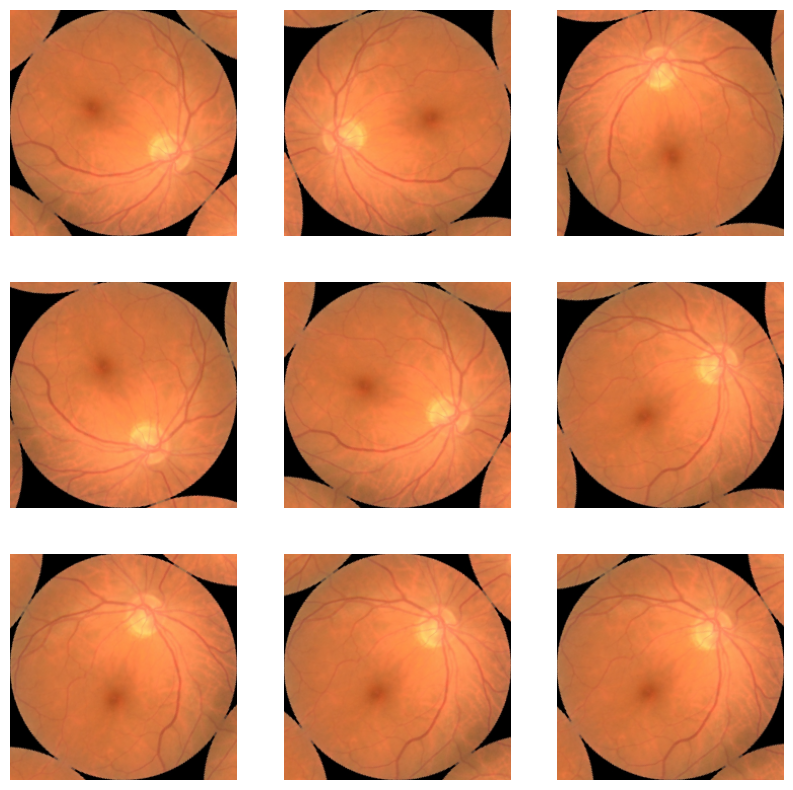

In [4]:
import matplotlib.pyplot as plt

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [5]:
import tensorflow as tf

base_model = tf.keras.applications.EfficientNetB5(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze EfficientNet
base_model.trainable = False


# Your custom classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    4,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 7, 7, 2048)     │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,521,723 (108.80 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 28,513,527 (108.77 MB)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
EPOCH = 20

loss0, accuracy0 = model.evaluate(val_dataset)

print("Loss:", loss0)
print("Accuracy:", accuracy0)

I0000 00:00:1787394767.053014     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 37s 938ms/step - accuracy: 0.3461 - loss: 1.3517
Loss: 1.3516793251037598
Accuracy: 0.3460620641708374


In [10]:
history = model.fit(train_dataset,
                    epochs=EPOCH,
                    validation_data=val_dataset,
                   verbose = 1)

Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 99s 417ms/step - accuracy: 0.6741 - loss: 0.8242 - val_accuracy: 0.7780 - val_loss: 0.6043
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7782 - loss: 0.5889 - val_accuracy: 0.8091 - val_loss: 0.5389
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.7942 - loss: 0.5349 - val_accuracy: 0.8234 - val_loss: 0.5115
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8170 - loss: 0.4882 - val_accuracy: 0.8473 - val_loss: 0.4664
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.8363 - loss: 0.4557 - val_accuracy: 0.8592 - val_loss: 0.4452
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8416 - loss: 0.4377 - val_accuracy: 0.8640 - val_loss: 0.4327
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.8523 - loss: 0.4205 - val_accuracy: 0.8496 - val_loss: 0.4308
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8541 - loss: 0

In [11]:
loss1, accuracy1 = model.evaluate(val_dataset)

print("Loss:", loss1)
print("Accuracy:", accuracy1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8592 - loss: 0.3825
Loss: 0.3824596405029297
Accuracy: 0.8591885566711426


In [12]:
!pip install tf2onnx onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 14.1 MB/s eta 0:00:00a 0:00:01


In [13]:
print(model.input_shape)
print(model.input.dtype)

(None, 224, 224, 3)
float32


In [14]:
import tf2onnx
import onnx

input_signature = [tf.TensorSpec(shape=[None, 224, 224, 3], dtype=tf.float32, name="input_layer")]

# 3. Convert the model to ONNX format
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature, opset=15)

# 4. Save the ONNX file to disk
onnx.save(onnx_model, "model.onnx")
print("Model successfully saved to model.onnx")

I0000 00:00:1787395115.481012      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1787395115.481318      58 single_machine.cc:376] Starting new session
I0000 00:00:1787395115.482622      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787395123.356291      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787395125.824503      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1787395125.824848      58 single_machine.cc:376] Starting new session
I0000 00:00:1787395125.829578      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 wi

Model successfully saved to model.onnx


In [15]:
!pip install shap

import shap
import numpy as np
import matplotlib.pyplot as plt

In [16]:
images, labels = next(iter(test_dataset))

print(images.shape)
print(labels.shape)

images_to_explain = images[:4]

(32, 224, 224, 3)
(32,)


/tmp/ipykernel_58/4109688171.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


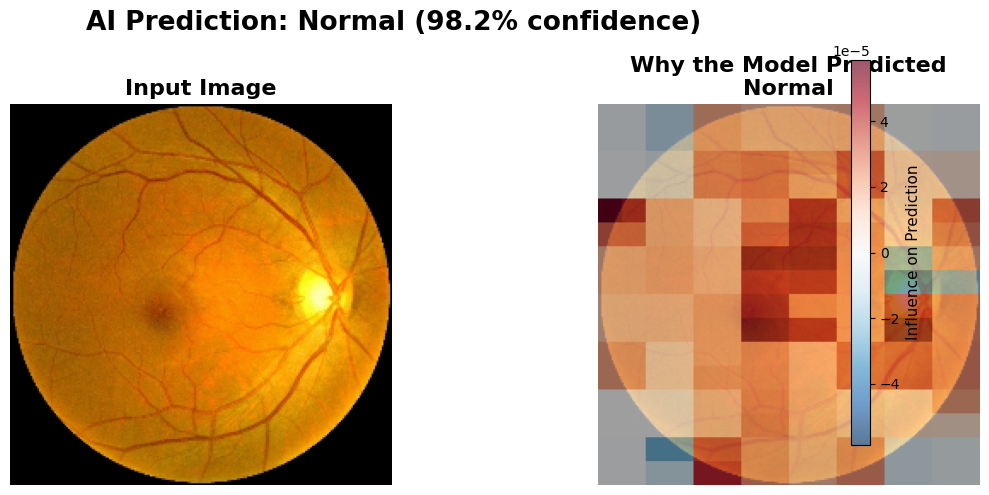

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Get the image
# --------------------------------------------------

image = images_to_explain[0]

# Convert 0-255 image to 0-1 ONLY for plotting
image_display = np.clip(image / 255.0, 0, 1)


# --------------------------------------------------
# Get SHAP values
# --------------------------------------------------

# For PartitionExplainer with a single explained output:
# shape is usually:
# (1, height, width, channels, 1)

values = shap_values.values[0]

# Remove output dimension
if values.ndim == 4:
    values = values[..., 0]

# Combine RGB SHAP values into one 2D heatmap
shap_map = np.sum(values, axis=-1)


# --------------------------------------------------
# Normalize visualization
# --------------------------------------------------

# Use percentiles instead of raw min/max.
# This makes weak but meaningful regions visible.

limit = np.percentile(
    np.abs(shap_map),
    98
)

shap_map = np.clip(
    shap_map,
    -limit,
    limit
)


# --------------------------------------------------
# Get model prediction
# --------------------------------------------------

prediction = model.predict(
    images_to_explain[:1],
    verbose=0
)[0]

predicted_index = np.argmax(prediction)
predicted_class = train_dataset.class_names[predicted_index]
confidence = prediction[predicted_index] * 100


# --------------------------------------------------
# Create visualization
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# LEFT: Original image
axes[0].imshow(image_display)
axes[0].set_title(
    "Input Image",
    fontsize=16,
    fontweight="bold"
)
axes[0].axis("off")


# RIGHT: SHAP heatmap
axes[1].imshow(image_display)

heatmap = axes[1].imshow(
    shap_map,
    cmap="RdBu_r",
    alpha=0.65,
    vmin=-limit,
    vmax=limit
)

axes[1].set_title(
    f"Why the Model Predicted\n{predicted_class.replace('_', ' ').title()}",
    fontsize=16,
    fontweight="bold"
)

axes[1].axis("off")


# --------------------------------------------------
# Color bar
# --------------------------------------------------

cbar = fig.colorbar(
    heatmap,
    ax=axes,
    fraction=0.025,
    pad=0.03
)

cbar.set_label(
    "Influence on Prediction",
    fontsize=11
)


# --------------------------------------------------
# Main title
# --------------------------------------------------

fig.suptitle(
    f"AI Prediction: {predicted_class.replace('_', ' ').title()} "
    f"({confidence:.1f}% confidence)",
    fontsize=19,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

In [20]:
model.predict(images_to_explain)

predictions = model.predict(images_to_explain)

for i, prediction in enumerate(predictions):
    predicted_class = np.argmax(prediction)

    print(
        f"Image {i}: "
        f"{train_dataset.class_names[predicted_class]} "
        f"({np.max(prediction) * 100:.2f}%)"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Image 0: cataract (90.06%)
Image 1: normal (99.61%)
Image 2: diabetic_retinopathy (89.53%)
Image 3: cataract (88.11%)
